## 1. 📦 Install & Import Libraries

In [9]:
import os
import numpy as np
from glob import glob
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.model_selection import train_test_split

import albumentations as A
from albumentations.pytorch import ToTensorV2

import matplotlib.pyplot as plt
from tqdm import tqdm

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device        : {DEVICE}")
print(f"GPUs available: {torch.cuda.device_count()}")

Device        : cuda
GPUs available: 2


## 2. ⚙️ Configuration & Hyperparameters

In [10]:
class CFG:
    DATA_DIR       = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"
    TRAIN_IMG_DIR  = os.path.join(DATA_DIR, "segmentation_task/train/images")
    TRAIN_MASK_DIR = os.path.join(DATA_DIR, "segmentation_task/train/masks")
    TEST_IMG_DIR   = os.path.join(DATA_DIR, "segmentation_task/test/images")
    TEST_MASK_DIR  = os.path.join(DATA_DIR, "segmentation_task/test/masks")

    IMG_SIZE     = 256
    IN_CHANNELS  = 3
    NUM_CLASSES  = 1      # Binary: tumor vs background

    EPOCHS       = 40
    BATCH_SIZE   = 32     # 16 per GPU across 2 T4s
    LR           = 2e-4
    VAL_SPLIT    = 0.15
    NUM_WORKERS  = 4

    SAVE_PATH    = "/kaggle/working/attention_unet_best.pth"
    BACKUP_PATH  = "/kaggle/working/attention_unet_epoch{}.pth"

## 3. 🗂️ Dataset Class

In [11]:
class BRISCSegDataset(Dataset):
    """
    Loads image + binary mask pairs from the
    segmentation_task folder.
    Images: .jpg
    Masks : .png (pixel > 127 = tumor)
    """
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask  = np.array(Image.open(self.mask_paths[idx]).convert("L"))
        mask  = (mask > 127).astype(np.float32)

        if self.transform:
            out   = self.transform(image=image, mask=mask)
            image = out["image"]
            mask  = out["mask"]

        mask = mask.unsqueeze(0) if isinstance(mask, torch.Tensor) \
               else torch.tensor(mask).unsqueeze(0)

        return image, mask

## 4. 🔄 Augmentation & DataLoaders

In [12]:
train_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.4),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(CFG.IMG_SIZE, CFG.IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2()
])

# Gather paths
train_images = sorted(glob(os.path.join(CFG.TRAIN_IMG_DIR, "*.jpg")))
train_masks  = sorted(glob(os.path.join(CFG.TRAIN_MASK_DIR, "*.png")))
test_images  = sorted(glob(os.path.join(CFG.TEST_IMG_DIR,  "*.jpg")))
test_masks   = sorted(glob(os.path.join(CFG.TEST_MASK_DIR,  "*.png")))

assert len(train_images) == len(train_masks), "Image/mask mismatch!"
print(f"Train: {len(train_images)} | Test: {len(test_images)}")

tr_imgs, vl_imgs, tr_msks, vl_msks = train_test_split(
    train_images, train_masks,
    test_size=CFG.VAL_SPLIT, random_state=SEED
)

train_ds = BRISCSegDataset(tr_imgs, tr_msks, transform=train_transform)
val_ds   = BRISCSegDataset(vl_imgs, vl_msks, transform=val_transform)
test_ds  = BRISCSegDataset(test_images, test_masks, transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
                          shuffle=True,  num_workers=CFG.NUM_WORKERS,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=CFG.NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=CFG.NUM_WORKERS,
                          pin_memory=True)

imgs, msks = next(iter(train_loader))
print(f"Image batch shape : {imgs.shape}")
print(f"Mask batch shape  : {msks.shape}")

Train: 3933 | Test: 860
Image batch shape : torch.Size([32, 3, 256, 256])
Mask batch shape  : torch.Size([32, 1, 256, 256])


## 5. 🏗️ Attention U-Net From Scratch

In [13]:
class DoubleConv(nn.Module):
    """Conv → BN → ReLU → Conv → BN → ReLU"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

In [18]:
class EncoderBlock(nn.Module):
    """DoubleConv + MaxPool. Returns (skip, downsampled)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = DoubleConv(in_ch, out_ch)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        skip = self.conv(x)
        down = self.pool(skip)
        return skip, down

In [19]:
class AttentionGate(nn.Module):
    """
    Attention Gate — the key addition over standard U-Net.

    In standard U-Net, skip connections pass ALL encoder
    features to the decoder unchanged. This includes
    irrelevant background regions which can confuse the
    decoder and reduce segmentation precision.

    The Attention Gate learns to SELECTIVELY highlight
    only the relevant spatial regions (tumor areas) in
    the skip connection, suppressing irrelevant background.

    How it works:
        g  = gating signal from decoder (coarse, semantic)
        x  = skip connection from encoder (fine, spatial)

        Both are projected to the same space (F_int channels)
        and added together. A sigmoid produces an attention
        map (values 0–1) where:
            1 = attend to this region (likely tumor)
            0 = suppress this region (background)

        The attention map is multiplied with the original
        skip connection — highlighting tumor, suppressing
        background — before passing to the decoder.

    Why does this help?
        Standard U-Net treats all skip connection features
        equally. Attention Gates make the decoder focus only
        on what matters, leading to:
        - More precise tumor boundary segmentation
        - Less false positives in background regions
        - Better performance especially on small tumors
    """
    def __init__(self, F_g, F_x, F_int):
        """
        F_g   : channels in gating signal (from decoder)
        F_x   : channels in skip connection (from encoder)
        F_int : intermediate channels (usually F_x // 2)
        """
        super().__init__()

        # Project gating signal to F_int channels
        # 1×1 conv — no spatial mixing, just channel projection
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        # Project skip connection to F_int channels
        self.W_x = nn.Sequential(
            nn.Conv2d(F_x, F_int, kernel_size=1,
                      stride=1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        # Collapse F_int channels → 1 channel attention map
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=False),
            nn.BatchNorm2d(1),
            nn.Sigmoid()   # Output: attention map in [0, 1]
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        """
        g : gating signal  (B, F_g, H/2, W/2) — from decoder
        x : skip connection (B, F_x, H,   W  ) — from encoder
        """
        # Project gating signal
        g1 = self.W_g(g)       # (B, F_int, H/2, W/2)

        # Project skip connection
        x1 = self.W_x(x)       # (B, F_int, H, W)

        # Upsample g1 to match x1 spatial size
        g1 = F.interpolate(g1, size=x1.shape[2:],
                           mode="bilinear", align_corners=False)

        # Add and activate — combines coarse semantic info
        # from decoder with fine spatial info from encoder
        psi = self.relu(g1 + x1)    # (B, F_int, H, W)

        # Generate attention map
        psi = self.psi(psi)          # (B, 1, H, W) values in [0,1]

        # Apply attention map to skip connection
        # Broadcasting: (B,1,H,W) * (B,F_x,H,W) → (B,F_x,H,W)
        # Each channel of x is scaled by the same spatial attention map
        return x * psi               # Attended skip connection

In [20]:
class AttentionDecoderBlock(nn.Module):
    """
    Decoder block with Attention Gate on the skip connection.

    Difference from standard DecoderBlock:
        Standard : concat(upsample(x), skip) → DoubleConv
        Attention : concat(upsample(x), AttentionGate(x, skip)) → DoubleConv

    The attention gate filters the skip connection before
    concatenation so the decoder only receives relevant features.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()

        # Learnable upsampling
        self.upsample = nn.ConvTranspose2d(
            in_ch, out_ch, kernel_size=2, stride=2
        )

        # Attention gate
        # F_g   = out_ch (channels after upsampling)
        # F_x   = out_ch (skip connection channels)
        # F_int = out_ch // 2 (intermediate projection)
        self.attention = AttentionGate(
            F_g=out_ch, F_x=out_ch, F_int=out_ch // 2
        )

        # After concat: out_ch (upsample) + out_ch (attended skip)
        self.conv = DoubleConv(out_ch * 2, out_ch)

    def forward(self, x, skip):
        # Upsample decoder features
        x = self.upsample(x)

        # Handle size mismatch from odd dimensions
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:],
                              mode="bilinear", align_corners=False)

        # Apply attention gate to skip connection
        # g = upsampled decoder features (coarse semantic signal)
        # x_skip = encoder skip (fine spatial detail)
        attended_skip = self.attention(g=x, x=skip)

        # Concatenate upsampled features with attended skip
        x = torch.cat([attended_skip, x], dim=1)

        return self.conv(x)

In [21]:
class AttentionUNet(nn.Module):
    """
    Attention U-Net for binary brain tumor segmentation.

    Identical to standard U-Net except every decoder block
    uses an Attention Gate on its skip connection.

    Architecture (features=[64, 128, 256, 512]):

    Encoder:
        Input   (B, 3,    256, 256)
        Enc1    (B, 64,   128, 128)  ──────────────────────────► skip1
        Enc2    (B, 128,  64,  64)   ──────────────────────────► skip2
        Enc3    (B, 256,  32,  32)   ──────────────────────────► skip3
        Enc4    (B, 512,  16,  16)   ──────────────────────────► skip4
        Bottle  (B, 1024, 8,   8)

    Decoder (with Attention Gates on skips):
        Dec4    (B, 512,  16,  16)  ◄── AttGate(skip4)
        Dec3    (B, 256,  32,  32)  ◄── AttGate(skip3)
        Dec2    (B, 128,  64,  64)  ◄── AttGate(skip2)
        Dec1    (B, 64,   128, 128) ◄── AttGate(skip1)
        Output  (B, 1,    256, 256)
    """
    def __init__(self, in_channels=3, num_classes=1,
                 features=[64, 128, 256, 512]):
        super().__init__()

        # Encoder
        self.encoders = nn.ModuleList()
        prev_ch = in_channels
        for f in features:
            self.encoders.append(EncoderBlock(prev_ch, f))
            prev_ch = f

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # Decoder with attention gates
        self.decoders = nn.ModuleList()
        prev_ch = features[-1] * 2
        for f in reversed(features):
            self.decoders.append(AttentionDecoderBlock(prev_ch, f))
            prev_ch = f

        # Output head
        self.output_conv = nn.Conv2d(features[0], num_classes,
                                     kernel_size=1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight,
                                        mode="fan_out",
                                        nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias,   0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # Encoder — collect skip connections
        skips = []
        for encoder in self.encoders:
            skip, x = encoder(x)
            skips.append(skip)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder — attention gates applied inside each block
        for decoder, skip in zip(self.decoders, reversed(skips)):
            x = decoder(x, skip)

        return self.output_conv(x)


In [22]:
# Instantiate
model = AttentionUNet(
    in_channels = CFG.IN_CHANNELS,
    num_classes = CFG.NUM_CLASSES
)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs!")
    model = nn.DataParallel(model)

model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total:,}")

# Forward pass check
dummy    = torch.randn(2, 3, CFG.IMG_SIZE, CFG.IMG_SIZE).to(DEVICE)
out      = model(dummy)
print(f"Input  : {dummy.shape}")
print(f"Output : {out.shape}")    # (2, 1, 256, 256)

Using 2 GPUs!
Total parameters: 31,388,201
Input  : torch.Size([2, 3, 256, 256])
Output : torch.Size([2, 1, 256, 256])


## 6. 📐 Loss Functions & Metrics

In [23]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        preds   = torch.sigmoid(logits)
        preds   = preds.view(preds.size(0), -1)
        targets = targets.view(targets.size(0), -1)
        inter   = (preds * targets).sum(dim=1)
        dice    = (2.0 * inter + self.smooth) / \
                  (preds.sum(dim=1) + targets.sum(dim=1) + self.smooth)
        return 1.0 - dice.mean()


class CombinedLoss(nn.Module):
    """BCE + Dice — handles class imbalance better than BCE alone."""
    def __init__(self):
        super().__init__()
        self.bce  = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):
        return 0.5 * self.bce(logits, targets) + \
               0.5 * self.dice(logits, targets)


def dice_score(logits, targets, threshold=0.5, smooth=1e-6):
    preds   = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (preds * targets).sum(dim=1)
    return ((2.0 * inter + smooth) /
            (preds.sum(dim=1) + targets.sum(dim=1) + smooth)
            ).mean().item()


def iou_score(logits, targets, threshold=0.5, smooth=1e-6):
    preds   = (torch.sigmoid(logits) > threshold).float()
    preds   = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)
    inter   = (preds * targets).sum(dim=1)
    union   = preds.sum(dim=1) + targets.sum(dim=1) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()


def save_checkpoint(model, optimizer, scheduler,
                    epoch, best_dice, history, path):
    state = model.module.state_dict() \
            if isinstance(model, nn.DataParallel) \
            else model.state_dict()
    torch.save({
        "epoch"    : epoch,
        "model"    : state,
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "best_dice": best_dice,
        "history"  : history
    }, path)


def load_checkpoint(path, device):
    ckpt  = torch.load(path, map_location=device)
    state = {k.replace("module.", ""): v
             for k, v in ckpt["model"].items()}
    m = AttentionUNet(
        in_channels = CFG.IN_CHANNELS,
        num_classes = CFG.NUM_CLASSES
    )
    m.load_state_dict(state)
    if torch.cuda.device_count() > 1:
        m = nn.DataParallel(m)
    return m.to(device), ckpt


criterion = CombinedLoss()
print("Loss, metrics and checkpoint helpers ready!")

Loss, metrics and checkpoint helpers ready!


## 7. 🚀 Training Loop

In [24]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_dice, total_iou = 0, 0, 0

    for images, masks in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        masks  = masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss   = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),
                                        max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total_dice += dice_score(logits.detach(), masks)
        total_iou  += iou_score(logits.detach(),  masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0

    for images, masks in tqdm(loader, desc="Val", leave=False):
        images = images.to(device)
        masks  = masks.to(device)
        logits = model(images)
        total_loss += criterion(logits, masks).item()
        total_dice += dice_score(logits, masks)
        total_iou  += iou_score(logits,  masks)

    n = len(loader)
    return total_loss / n, total_dice / n, total_iou / n


print("Train and validate functions ready!")

Train and validate functions ready!


In [25]:
optimizer = Adam(model.parameters(),
                 lr=CFG.LR, weight_decay=1e-5)
scheduler = CosineAnnealingLR(optimizer,
                               T_max=CFG.EPOCHS, eta_min=1e-6)

history   = {"train_loss":[], "val_loss":[],
             "train_dice":[], "val_dice":[],
             "train_iou" :[], "val_iou" :[]}
best_dice = 0.0

print(f"{'Epoch':>5} | {'TrLoss':>7} | {'TrDice':>7} | "
      f"{'VlLoss':>7} | {'VlDice':>7} | {'VlIoU':>6}")
print("-" * 55)

for epoch in range(1, CFG.EPOCHS + 1):

    tr_loss, tr_dice, tr_iou = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    vl_loss, vl_dice, vl_iou = validate(
        model, val_loader, criterion, DEVICE
    )
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_dice"].append(tr_dice)
    history["val_dice"].append(vl_dice)
    history["train_iou"].append(tr_iou)
    history["val_iou"].append(vl_iou)

    if vl_dice > best_dice:
        best_dice = vl_dice
        save_checkpoint(model, optimizer, scheduler,
                        epoch, best_dice, history,
                        CFG.SAVE_PATH)
        tag = " ✅"
    else:
        tag = ""

    if epoch % 5 == 0:
        save_checkpoint(model, optimizer, scheduler,
                        epoch, best_dice, history,
                        CFG.BACKUP_PATH.format(epoch))
        print(f"  💾 Backup saved at epoch {epoch}")

    print(f"{epoch:>5} | {tr_loss:>7.4f} | {tr_dice:>7.4f} | "
          f"{vl_loss:>7.4f} | {vl_dice:>7.4f} | "
          f"{vl_iou:>6.4f}{tag}")

print(f"\nBest Validation Dice: {best_dice:.4f}")

Epoch |  TrLoss |  TrDice |  VlLoss |  VlDice |  VlIoU
-------------------------------------------------------


    1 |  0.4691 |  0.2317 |  0.2883 |  0.5087 | 0.4052 ✅


    2 |  0.3277 |  0.4359 |  0.2323 |  0.6089 | 0.5035 ✅


    3 |  0.2657 |  0.5485 |  0.2226 |  0.6255 | 0.5184 ✅


    4 |  0.2290 |  0.6102 |  0.1992 |  0.6618 | 0.5753 ✅


...

   36 |  0.0954 |  0.8353 |  0.0937 |  0.8399 | 0.7593


   37 |  0.0954 |  0.8356 |  0.0935 |  0.8403 | 0.7595 ✅


   38 |  0.0965 |  0.8335 |  0.0941 |  0.8390 | 0.7588


   39 |  0.0952 |  0.8354 |  0.0932 |  0.8409 | 0.7607 ✅


  💾 Backup saved at epoch 40
   40 |  0.0956 |  0.8351 |  0.0932 |  0.8407 | 0.7610

Best Validation Dice: 0.8409


## 8. 📊 Plot Training Curves

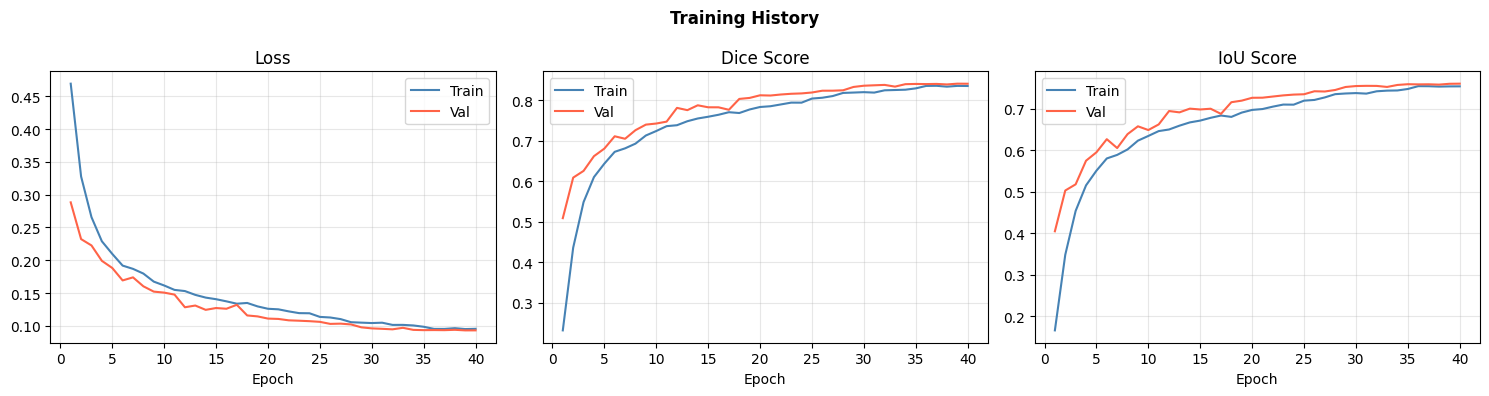

In [26]:
epochs = range(1, CFG.EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Training History", fontweight="bold")

for ax, (tr_key, vl_key), title in zip(
    axes,
    [("train_loss","val_loss"), ("train_dice","val_dice"), ("train_iou","val_iou")],
    ["Loss", "Dice Score", "IoU Score"]
):
    ax.plot(epochs, history[tr_key], label="Train", color="steelblue")
    ax.plot(epochs, history[vl_key], label="Val",   color="tomato")
    ax.set_title(title); ax.set_xlabel("Epoch")
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/training_curves.png", dpi=150)
plt.show()

## 9. 🧪 Test Evaluation & Visualization

In [28]:
# Load the raw checkpoint file
checkpoint = torch.load(CFG.SAVE_PATH, map_location=DEVICE)

# If saved as a full checkpoint dict (with epoch, optimizer etc.)
# extract just the model weights
if "model" in checkpoint:
    state_dict = checkpoint["model"]
else:
    state_dict = checkpoint  # saved with just model.state_dict()

# Remove the "module." prefix that DataParallel adds
# "module.encoders.0.conv..." → "encoders.0.conv..."
cleaned_state_dict = {
    k.replace("module.", ""): v
    for k, v in state_dict.items()
}

# Load into a plain UNet (no DataParallel needed for inference)
model = AttentionUNet(in_channels=CFG.IN_CHANNELS, num_classes=CFG.NUM_CLASSES).to(DEVICE)
model.load_state_dict(cleaned_state_dict)

print("Model loaded successfully!")

# Evaluate
ts_loss, ts_dice, ts_iou = validate(model, test_loader, criterion, DEVICE)
print(f"Test Loss : {ts_loss:.4f}")
print(f"Test Dice : {ts_dice:.4f}")
print(f"Test IoU  : {ts_iou:.4f}")

Model loaded successfully!


Test Loss : 0.0869
Test Dice : 0.8512
Test IoU  : 0.7767


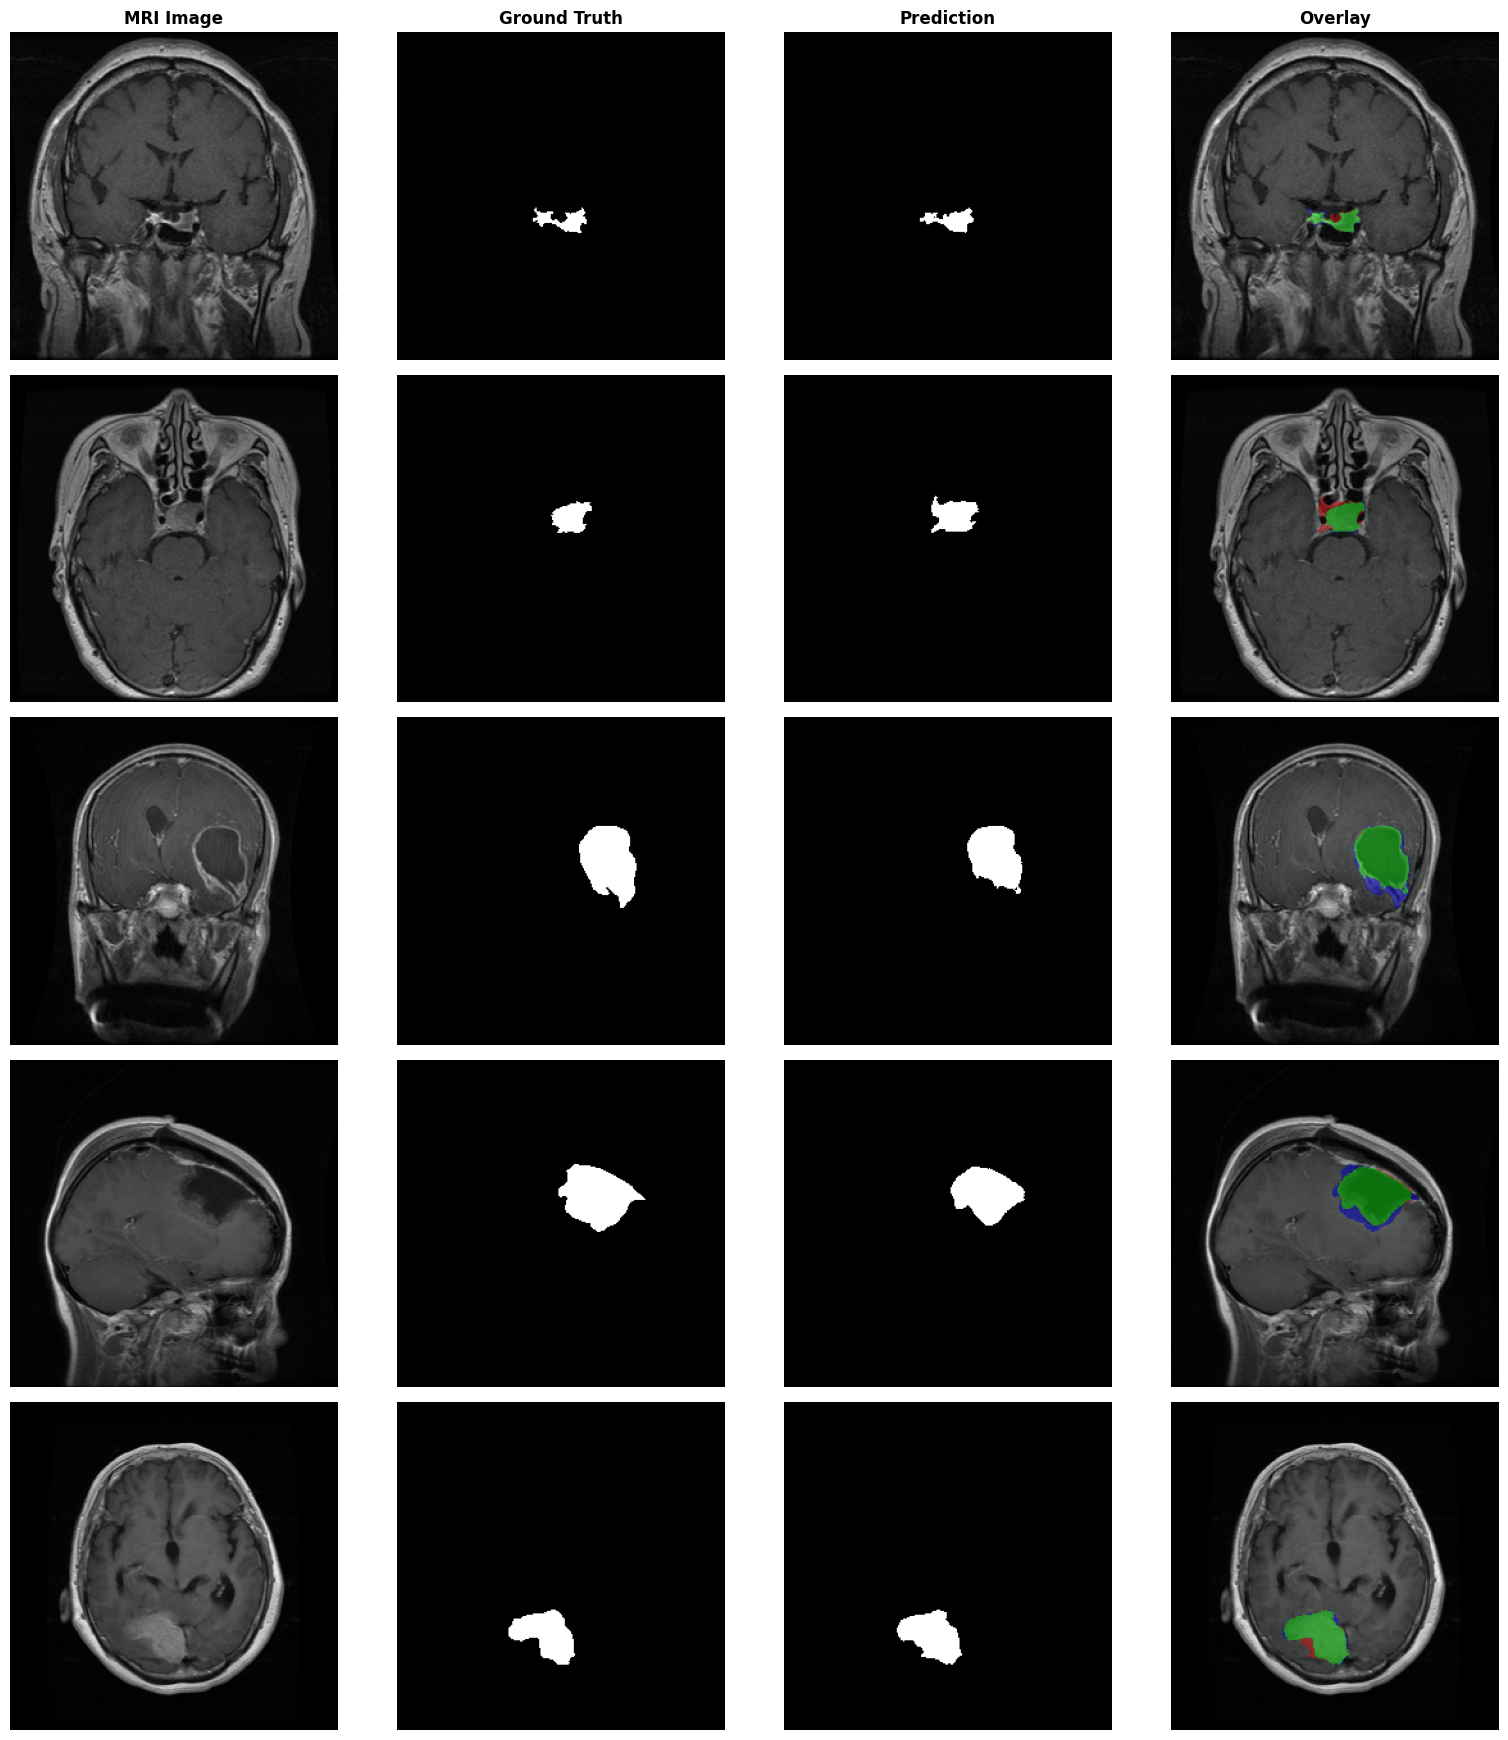

🟢 True Positive  🔴 False Positive  🔵 False Negative


In [29]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, n=5):
    model.eval()
    indices = np.random.choice(len(dataset), n, replace=False)

    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])

    fig, axes = plt.subplots(n, 4, figsize=(16, n * 3.5))
    for col, title in enumerate(["MRI Image", "Ground Truth", "Prediction", "Overlay"]):
        axes[0, col].set_title(title, fontweight="bold")

    for row, idx in enumerate(indices):
        img_t, msk_t = dataset[idx]

        logit = model(img_t.unsqueeze(0).to(device))
        pred  = (torch.sigmoid(logit) > 0.5).squeeze().cpu().numpy()

        # Denormalize for display
        img_np = img_t.permute(1,2,0).numpy()
        img_np = (img_np * std + mean).clip(0, 1)
        img_u8 = (img_np * 255).astype(np.uint8)

        gt = msk_t.squeeze().numpy()

        # Color-coded overlay:
        # Green = True Positive (correctly found tumor)
        # Red   = False Positive (predicted tumor where there's none)
        # Blue  = False Negative (missed actual tumor)
        overlay = img_u8.copy()
        overlay[(pred==1) & (gt==1)] = [0, 200, 0]
        overlay[(pred==1) & (gt==0)] = [200, 0, 0]
        overlay[(pred==0) & (gt==1)] = [0, 0, 200]

        import cv2
        overlay = cv2.addWeighted(img_u8, 0.5, overlay, 0.5, 0)

        inter = (pred * gt).sum()
        s_dice = (2*inter + 1e-6) / (pred.sum() + gt.sum() + 1e-6)

        axes[row,0].imshow(img_np)
        axes[row,1].imshow(gt, cmap="gray")
        axes[row,2].imshow(pred, cmap="gray")
        axes[row,3].imshow(overlay)
        axes[row,3].set_xlabel(f"Dice: {s_dice:.3f}", fontsize=9)

        for ax in axes[row]: ax.axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/predictions.png", dpi=150)
    plt.show()
    print("🟢 True Positive  🔴 False Positive  🔵 False Negative")

visualize_predictions(model, test_ds, DEVICE, n=5)

Testing: 100%|██████████| 27/27 [00:16<00:00,  1.63it/s]


Test Loss : 0.0869
Test Dice : 0.8512
Test IoU  : 0.7767


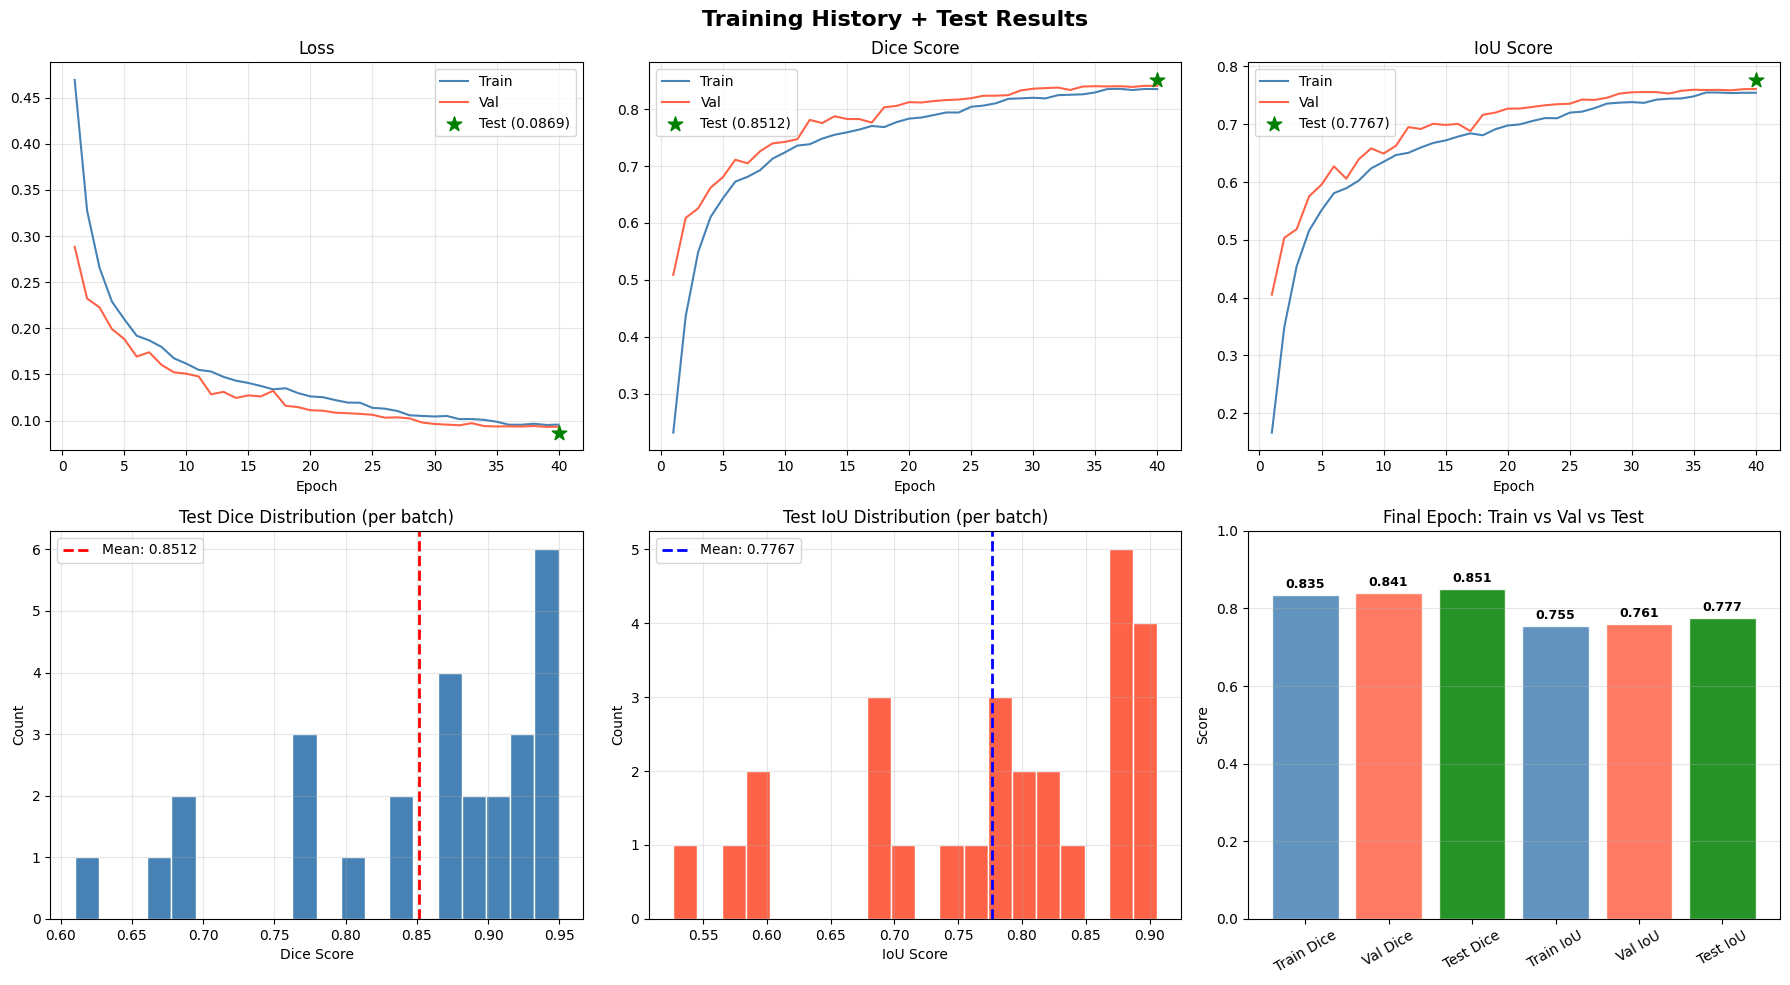

In [30]:
@torch.no_grad()
def evaluate_and_plot(model, test_loader, criterion, history, device):
    model.eval()
    total_loss, total_dice, total_iou = 0, 0, 0
    all_dice, all_iou = [], []   # per-batch scores for distribution plot

    for images, masks in tqdm(test_loader, desc="Testing"):
        images, masks = images.to(device), masks.to(device)
        logits = model(images)

        total_loss += criterion(logits, masks).item()
        
        # Track per-batch metrics to plot their distribution
        b_dice = dice_score(logits, masks)
        b_iou  = iou_score(logits, masks)
        all_dice.append(b_dice)
        all_iou.append(b_iou)

        total_dice += b_dice
        total_iou  += b_iou

    n = len(test_loader)
    ts_loss = total_loss / n
    ts_dice = total_dice / n
    ts_iou  = total_iou  / n

    print(f"Test Loss : {ts_loss:.4f}")
    print(f"Test Dice : {ts_dice:.4f}")
    print(f"Test IoU  : {ts_iou:.4f}")

    # ── Plot ──────────────────────────────────────────────────────────
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Training History + Test Results", fontsize=16, fontweight="bold")

    # ── Row 1: Training curves with test point overlaid ───────────────

    # Loss curve
    axes[0,0].plot(epochs, history["train_loss"], label="Train", color="steelblue")
    axes[0,0].plot(epochs, history["val_loss"],   label="Val",   color="tomato")
    axes[0,0].scatter(len(epochs), ts_loss, color="green", zorder=5,
                      s=120, label=f"Test ({ts_loss:.4f})", marker="*")
    axes[0,0].set_title("Loss");  axes[0,0].set_xlabel("Epoch")
    axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

    # Dice curve
    axes[0,1].plot(epochs, history["train_dice"], label="Train", color="steelblue")
    axes[0,1].plot(epochs, history["val_dice"],   label="Val",   color="tomato")
    axes[0,1].scatter(len(epochs), ts_dice, color="green", zorder=5,
                      s=120, label=f"Test ({ts_dice:.4f})", marker="*")
    axes[0,1].set_title("Dice Score"); axes[0,1].set_xlabel("Epoch")
    axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

    # IoU curve
    axes[0,2].plot(epochs, history["train_iou"], label="Train", color="steelblue")
    axes[0,2].plot(epochs, history["val_iou"],   label="Val",   color="tomato")
    axes[0,2].scatter(len(epochs), ts_iou, color="green", zorder=5,
                      s=120, label=f"Test ({ts_iou:.4f})", marker="*")
    axes[0,2].set_title("IoU Score"); axes[0,2].set_xlabel("Epoch")
    axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

    # ── Row 2: Test-specific plots ─────────────────────────────────────

    # Dice distribution across test batches
    axes[1,0].hist(all_dice, bins=20, color="steelblue", edgecolor="white")
    axes[1,0].axvline(ts_dice, color="red", linestyle="--", linewidth=2,
                      label=f"Mean: {ts_dice:.4f}")
    axes[1,0].set_title("Test Dice Distribution (per batch)")
    axes[1,0].set_xlabel("Dice Score"); axes[1,0].set_ylabel("Count")
    axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

    # IoU distribution across test batches
    axes[1,1].hist(all_iou, bins=20, color="tomato", edgecolor="white")
    axes[1,1].axvline(ts_iou, color="blue", linestyle="--", linewidth=2,
                      label=f"Mean: {ts_iou:.4f}")
    axes[1,1].set_title("Test IoU Distribution (per batch)")
    axes[1,1].set_xlabel("IoU Score"); axes[1,1].set_ylabel("Count")
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    # Summary bar chart: Train vs Val vs Test for final epoch
    axes[1,2].bar(
        ["Train Dice", "Val Dice", "Test Dice",
         "Train IoU",  "Val IoU",  "Test IoU"],
        [history["train_dice"][-1], history["val_dice"][-1], ts_dice,
         history["train_iou"][-1],  history["val_iou"][-1],  ts_iou],
        color=["steelblue","tomato","green",
               "steelblue","tomato","green"],
        edgecolor="white", alpha=0.85
    )
    axes[1,2].set_title("Final Epoch: Train vs Val vs Test")
    axes[1,2].set_ylabel("Score")
    axes[1,2].set_ylim(0, 1)
    axes[1,2].tick_params(axis="x", rotation=30)
    axes[1,2].grid(axis="y", alpha=0.3)

    # Annotate bars with values
    for bar in axes[1,2].patches:
        axes[1,2].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.3f}",
            ha="center", va="bottom", fontsize=9, fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig("/kaggle/working/full_results.png", dpi=150, bbox_inches="tight")
    plt.show()

    return ts_loss, ts_dice, ts_iou


ts_loss, ts_dice, ts_iou = evaluate_and_plot(model, test_loader, criterion, history, DEVICE)